# The fear gauge takes weekends off — by design 📅
### The VIX weekend seesaw: a *guaranteed* calendar pattern hiding in the index's own formula

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ETP_harvest%3F: Busted](https://img.shields.io/badge/ETP_harvest%3F-Busted-8b949e?style=flat-square)

Here's a pattern you can set your watch by. The VIX — Wall Street's "fear gauge" — tends to **fall on Fridays** and **jump on Mondays**. Not because the world gets safer before the weekend and scarier after it, but because of **arithmetic**: the VIX measures expected market wobble over the next **30 calendar days**, and a weekend is two calendar days when almost nothing can wobble (the market is closed). When the weekend slides *into* that 30-day window on Thursday/Friday, the number gets marked down; when it slides *out* over the weekend, Monday's print pops back up.

One warning before we start: the folk version of this story often gets the direction **backwards** ("the VIX drifts up into Friday and drops on Monday"). The arithmetic — and 36 years of tape — say the exact opposite.

> 📓 **Plain-language layer.** Want the *t*-stats, the day-count model and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
WD = ["Mon", "Tue", "Wed", "Thu", "Fri"]

from vix_weekend_arithmetic import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    VIX = data.load_vix()
    VIXY = data.load_vixy()
    D = st.dlog_pct(VIX)
else:
    VIX = VIXY = D = None
print("real ^VIX/VIXY cache present:", HAVE_REAL,
      "| daily changes:", (0 if D is None else len(D)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1990-01-03', 'end': '2026-06-30', 'n_days': 9190, 'table': [('Mon', 1.805, 10.25, 1733), ('Tue', -0.158, -1.05, 1886), ('Wed', -0.564, -3.82, 1883), ('Thu', 0.013, 0.09, 1849), ('Fri', -0.977, -6.02, 1839)], 'mon_mean': 1.805, 'fri_mean': -0.977, 'spread': 2.783, 'welch_t': 11.61, 'hac_t': 11.19, 'hac_mon_t': 10.23, 'hac_fri_t': -3.96, 'p_placebo': '< 1/20,000', 'race': [('Mon', 4.77, 1.81, 1.53), ('Tue', 0.0, -0.16, 0.0), ('Wed', 0.0, -0.56, 0.0), ('Thu', -2.33, 0.01, -0.76), ('Fri', -2.44, -0.98, -0.77)], 'f_implied': 0.597, 'fit_rmse': 0.46, 'decades': [('1990-1999', 2.345, -1.12, 3.464, 8.77), ('2000-2009', 1.856, -0.593, 2.449, 6.63), ('2010-2019', 1.565, -1.217, 2.781, 5.2), ('2020-2026', 1.247, -0.981, 2.229, 3.34)], 'gap_post': 2.067, 'gap_pre': -0.997, 'gap_mid': -0.379, 'n_post': 1904, 'n_pre': 1904, 'gap_t_post_pre': 13.21, 'gap_t_post_mid': 12.83, 'vixy_mon': -0.324, 'vixy_mon_t': -1.72, 'vixy_rest': -0.136, 'vixy_welch': -0.92, 'vix_mon_matched': 1.626, 'n_weekends': 728, 'vixy_years': 15.5, 'trades_yr': 47, 'harvest': [(2.0, -15.2, -17.1), (5.0, -15.2, -19.9), (10.0, -15.2, -24.6)], 'syn': [(1.0, -0.111, -0.63, -0.64, 1.0), (0.3, 4.342, 24.49, 25.09, 0.308)], 'fp_vix': '63115cff08dc', 'fp_vixy': '829eafeefcc4', 'asof': '2026-06-30'}


real ^VIX/VIXY cache present: True | daily changes: 9190


## The answer first

| Question | Answer |
|---|---|
| Is there really a weekend seesaw in the VIX? | **Yes — a huge one.** Mondays average **+1.8%**, Fridays **−1.0%**, every decade since 1990. The odds of this being luck are less than 1 in 20,000. |
| Which way does it go? | **Down into Friday, up on Monday** — exactly what the formula's calendar arithmetic predicts, and the *opposite* of the popular "up into Friday" retelling. |
| Is it *pure* arithmetic? | **Mostly.** The tape shows about **40%** of the full-arithmetic size — option markets price a weekend day at roughly **60%** of a normal trading day's risk, not zero. |
| Can you trade it? | **No.** Everything you can actually buy (VIX futures, ETPs like VXX/VIXY) already *knows* the calendar. The literal "hold over the weekend" trade **loses ~20%/yr** after costs. |

> A guaranteed pattern that everyone can see, in an index nobody can buy — the market's politest way of saying *no free lunch*.

## 1 · The claim

> *"The VIX has a day-of-week drift baked into its own formula — pure calendar-variance arithmetic, a guaranteed pattern hiding in plain sight."*

The mechanism is real math, not folklore. The VIX is (the square root of) the market's expected S&P-500 variance over the next **30 calendar days**, annualized on a calendar clock. But variance mostly happens while the market **trades**. Count the days in the window:

- quoted on **Monday**: the next 30 days hold **22 trading + 8 weekend** days,
- quoted on **Friday**: they hold **20 trading + 10 weekend** days.

Same formula, different fuel. If weekends carried zero risk, Friday's VIX would print about **5% lower** than Monday's for the *same* underlying fear — so the index would mechanically sag into every weekend and snap back after it.

## 2 · So what?

Three things ride on this. **First**, anyone reading the VIX as a pure fear thermometer is reading a thermometer that dips every Friday for non-fear reasons — Monday's "vol spike" headlines are partly the calendar talking. **Second**, if the pattern is this guaranteed, the obvious question is whether you can *harvest* it — buy vol Friday, sell it Monday. **Third**, the size of the seesaw quietly measures something deep: how much the options market thinks a weekend is worth, in risk terms.

## 3 · How would we even know?

We take **every** ^VIX close since 1990 — **9,190** daily changes through 2026-06-30 — and simply sort them by the day of the week they land on. Then we:

1. **Measure the seesaw.** Average change by weekday, with honest significance tests.
2. **Race it against the arithmetic.** The day-count model has one free knob — how much of a trading day's risk a weekend day carries. We fit it and see how much of the pattern the formula explains.
3. **Try to cash it.** Buy a real, tradable VIX product (VIXY) at Friday's close, sell at Monday's close, every weekend for 15 years, minus costs.

## 4 · The teardown — let's actually look

**The day-of-week table.** Average daily change of the VIX by weekday, 1990–2026.

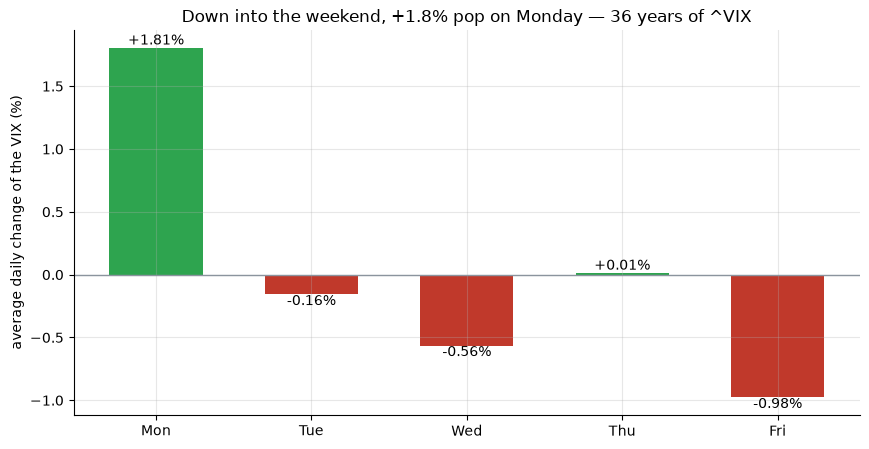

weekday means (%): [1.805, -0.158, -0.564, 0.013, -0.977]


In [2]:
if HAVE_REAL:
    tbl = st.weekday_table(D)
    means = [r['mean_pct'] for r in tbl]
else:
    means = [r[1] for r in R['table']]
colors = [GREEN if m > 0 else RED for m in means]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(WD, means, color=colors, width=.6)
for i, v in enumerate(means):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom' if v > 0 else 'top')
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('average daily change of the VIX (%)')
ax.set_title('Down into the weekend, +1.8% pop on Monday — 36 years of ^VIX')
plt.tight_layout(); plt.show()
print('weekday means (%):', [round(m, 3) for m in means])

There's the seesaw — and the **sign**. Mondays average **+1.8%**, Fridays **-1.0%**: the VIX falls *into* the weekend and pops *after* it. The Monday-minus-Friday gap is **+2.8% per day** — for scale, that's a bigger day-of-week gap than almost any calendar effect on any tape this desk has run. The quants notebook shows it's about **11 standard errors** from zero, in **every** decade, and that it follows holiday weekends too (it's the *market closure*, not the word "Monday").

**Is it the arithmetic?** The day-count model has one knob: how much of a trading day's variance a weekend day carries (call it *f*). If *f* = 0 (weekends are risk-free), the model predicts a **+4.8%** Monday pop. If *f* = 1 (weekends are full trading days), it predicts **nothing**. Fit *f* to the tape and compare shapes.

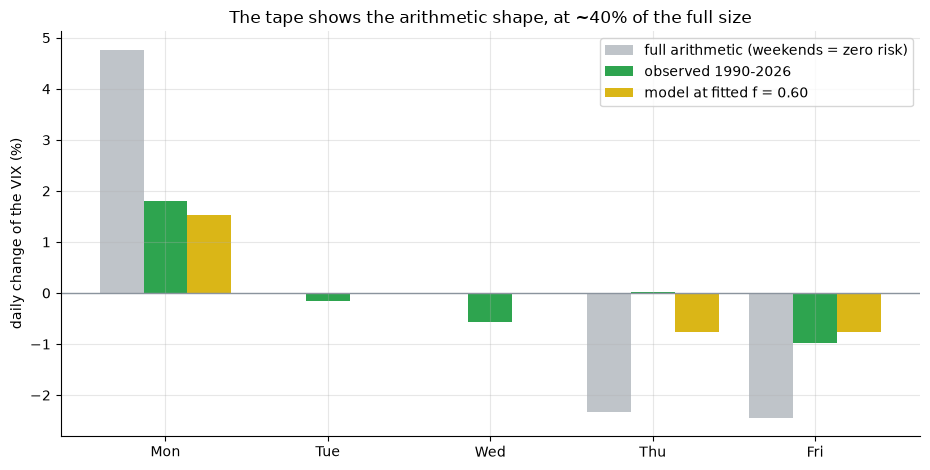

implied weekend fraction f = 0.597 (a weekend day is priced at ~60% of a trading day)


In [3]:
if HAVE_REAL:
    imp = st.implied_weekend_fraction(D)
    obs = [imp['obs'][k] for k in range(5)]
    full = [imp['model_full_arithmetic'][k] for k in range(5)]
    fit = [imp['model_at_fit'][k] for k in range(5)]
    f_hat = imp['f']
else:
    obs = [r[2] for r in R['race']]; full = [r[1] for r in R['race']]
    fit = [r[3] for r in R['race']]; f_hat = R['f_implied']
x = np.arange(5); w = 0.27
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.bar(x - w, full, w, color=GREY, alpha=.55, label='full arithmetic (weekends = zero risk)')
ax.bar(x,     obs,  w, color=GREEN, label='observed 1990-2026')
ax.bar(x + w, fit,  w, color=AMBER, label=f'model at fitted f = {f_hat:.2f}')
ax.set_xticks(x); ax.set_xticklabels(WD); ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('daily change of the VIX (%)')
ax.set_title('The tape shows the arithmetic shape, at ~40% of the full size')
ax.legend(); plt.tight_layout(); plt.show()
print(f'implied weekend fraction f = {f_hat:.3f} '
      f'(a weekend day is priced at ~{f_hat*100:.0f}% of a trading day)')

The tape (green) has exactly the model's shape — sag late in the week, pop on Monday — but at about **40%** of the zero-risk-weekend size (grey). The best-fit knob says the market prices a weekend day at **~60%** of a trading day's risk (*f* ≈ 0.6). Which makes sense: markets are closed on weekends, but wars, elections and banking crises are not. The seesaw is the arithmetic **times** the market's partial weekend discount.

**Now try to cash it.** The VIX itself is a formula — you can't buy it. The closest tradable thing is a VIX-futures ETP (we use VIXY, 2011+). If the Monday pop leaks into the product, buying Friday's close and selling Monday's close should print money.

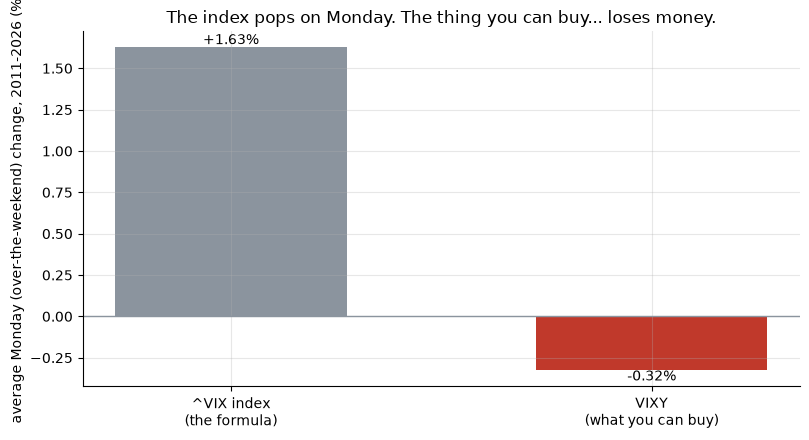

index Monday mean +1.63%  vs tradable VIXY Monday mean -0.32%


In [4]:
if HAVE_REAL:
    v = st.vixy_weekend(VIXY, VIX, cost_bps=5.0)
    pair = [v['vix_mon_mean_pct'], v['mon_mean_pct']]
else:
    pair = [R['vix_mon_matched'], R['vixy_mon']]
fig, ax = plt.subplots(figsize=(8.2, 4.5))
ax.bar(['^VIX index\n(the formula)', 'VIXY\n(what you can buy)'], pair,
       color=[GREY, RED], width=.55)
for i, v_ in enumerate(pair):
    ax.annotate(f'{v_:+.2f}%', (i, v_), ha='center', va='bottom' if v_ > 0 else 'top')
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('average Monday (over-the-weekend) change, 2011-2026 (%)')
ax.set_title('The index pops on Monday. The thing you can buy... loses money.')
plt.tight_layout(); plt.show()
print(f'index Monday mean {pair[0]:+.2f}%  vs tradable VIXY Monday mean {pair[1]:+.2f}%')

And there the dream dies. Over the same 728 weekends the **index** jumped **+1.63%** on the average Monday — but **VIXY**, the thing you can actually buy, *lost* **-0.32%**. Why? VIX futures are bets on where the index will be at expiry, priced by people who own calendars: Friday's futures price already includes Monday's mechanical pop. What's left is the product's ordinary running cost. The literal weekend-hold strategy loses **~20%/yr** after costs.

## 5 · The verdict

- **Signal — Real.** The weekend seesaw is enormous (+2.8%/day Monday-vs-Friday, ~11 standard errors, every decade, holidays included) and its direction is exactly what the formula's calendar arithmetic predicts — **down into Friday, up on Monday**. (The popular "up-into-Friday" version is backwards.)
- **Tradability — Mirage.** The index isn't tradable, and the tradable products are priced by people who can count weekends: the harvest trade loses ~20%/yr net.
- **"Can a VIX ETP harvest the Monday pop?" — Busted.** 728 weekends, 15.5 years: the ETP's weekend return is *negative*. The pattern lives in the formula, not in any price you can touch.

## 6 · Going further 🚪

- **Read the VIX with weekday glasses.** A Friday VIX of 18 and a Monday VIX of 18.5 can be the *same* fear level — the difference is the calendar. Monday "vol spike" stories deserve a 1.8% haircut before you believe them.
- **The weekend is worth ~60% of a trading day.** That fitted *f* is a live estimate of how the options market prices non-trading time — academics found the same thing in option prices directly (Jones & Shemesh 2018).
- **Siblings on the desk.** The *equity* weekend effect ([90-weekend](../../90-weekend/)) is a different (and mostly dead) claim; the VIX-ETP bleed the harvest trade drowned in is measured in [375-vxx-roll-decay](../../375-vxx-roll-decay/).

*Think you've found a corner where the weekend arithmetic leaks into something tradable — weekly options, VIX futures near expiry? Show the net P&L after the roll and we'll talk.*